# 04 · Statistical Analysis
Hypothesis tests (`src/statistics/hypothesis_tests.py`), a small supporting churn model
(`src/statistics/churn_model.py`) and sample-size planning for a *hypothetical* experiment.

* **alpha = 0.05** on **Holm-adjusted** p-values: 11 related tests on the same data would otherwise inflate the
  false-positive rate (about 43% chance of at least one false positive without correction).
* The churn-dimension chi-square tests in notebook 03 are Holm-adjusted across their own family of 17 dimensions, so
  the same dimension (e.g. industry) shows a different adjusted p-value there than in this 11-test family.
* **No A/B test exists in this dataset** (no experiment ID, variant, exposure or assignment fields). Every comparison
  below is observational.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60, "display.width", 200, "display.float_format", "{:,.4f}".format)

from src.utils.io import load_all
from src.utils.config import FIGURES_DIR
from src.utils.plotting import set_style
from src.analysis import marts, retention as ret
from src.statistics import hypothesis_tests as ht, churn_model, experiment_design
set_style()
t = load_all()
af, _ = marts.build_account_features(t)
a = ret.account_frame(af)

## 1. Hypothesis tests

In [2]:
tests = ht.run_tests(af, t["subscriptions"], t["feature_usage"], a, t["support_tickets"])
tests[["test_id", "business_question", "test", "statistic_name", "statistic", "p_value", "p_holm", "effect_size_name", "effect_size", "reject_h0"]]

,test_id,business_question,test,statistic_name,statistic,p_value,p_holm,effect_size_name,effect_size,reject_h0
0,T1,Is churn significantly different across subscr...,Pearson chi-square test of independence,chi2 (dof=2),0.0014,0.9993,1.0000,Cramer's V,0.0017,False
1,T2,Does churn differ by acquisition channel?,Pearson chi-square test of independence,chi2 (dof=4),8.3566,0.0794,0.7936,Cramer's V,0.1293,False
2,T3,Does churn differ by customer industry?,Pearson chi-square test of independence,chi2 (dof=4),8.8232,0.0657,0.7224,Cramer's V,0.1328,False
3,T4,Is retention significantly different between h...,Two-proportion z-test,z,1.7273,0.0841,0.7936,Cohen's h,0.1549,False
4,T5,Do high-engagement accounts survive longer bef...,Log-rank test (right-censored at 2024-12-31),chi2 (dof=1),0.9356,0.3334,1.0000,difference in share with churn event,0.0080,False
5,T6,Is feature adoption breadth associated with re...,Two-proportion z-test,z,1.4505,0.1469,1.0000,Cohen's h,0.1324,False
6,T7,Do churned accounts use the product less than ...,Mann-Whitney U (two-sided),U,"23,143.5000",0.2059,1.0000,rank-biserial r,-0.0790,False
7,T8,Do subscriptions on different plans stay activ...,"Log-rank test (3 groups, right-censored at 202...",chi2 (dof=2),0.5158,0.7727,1.0000,max - min ended share,0.0049,False
8,T9,Is having an escalated support ticket associat...,Fisher's exact test (2x2),odds ratio,1.2519,0.4036,1.0000,odds ratio,1.2519,False
9,T10,Do beta feature usage events generate more err...,Mann-Whitney U (two-sided),U,"28,470,682.5000",0.7402,1.0000,rank-biserial r,0.0033,False


In [3]:
display(Markdown(ht.to_markdown(tests)))

# Statistical Tests (auto-generated)

Generated by `python -m src.run_analysis`. alpha = 0.05, Holm correction across 11 tests. All comparisons are observational; none is an A/B test.

## T1. Is churn significantly different across subscription plans?

- **Null hypothesis:** Account churn rate is the same for every plan_tier.
- **Alternative hypothesis:** Account churn rate differs for at least one plan_tier.
- **Test:** Pearson chi-square test of independence
- **Assumptions:** Independent accounts; expected cell counts >= 5 (min expected = 33.9).
- **Observed:** Pro: 21.9% (n=178); Basic: 22.0% (n=168); Enterprise: 22.1% (n=154)
- **Test statistic:** chi2 (dof=2) = 0.0014
- **p-value:** raw 0.9993; Holm-adjusted 1
- **Confidence interval:** n/a (omnibus test); per-group Wilson CIs in churn_by_segment.csv
- **Effect size:** Cramer's V = 0.0017
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.9993): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Plan tier is not a useful churn-targeting lever on its own; look at behaviour and channel instead.

## T2. Does churn differ by acquisition channel?

- **Null hypothesis:** Account churn rate is the same for every referral_source.
- **Alternative hypothesis:** Account churn rate differs for at least one referral_source.
- **Test:** Pearson chi-square test of independence
- **Assumptions:** Independent accounts; expected cell counts >= 5 (min expected = 19.6).
- **Observed:** partner: 14.6% (n=89); organic: 17.5% (n=114); ads: 23.5% (n=98); other: 24.3% (n=103); event: 30.2% (n=96)
- **Test statistic:** chi2 (dof=4) = 8.3566
- **p-value:** raw 0.07936; Holm-adjusted 0.7936
- **Confidence interval:** n/a (omnibus test); per-group Wilson CIs in churn_by_segment.csv
- **Effect size:** Cramer's V = 0.1293
- **Interpretation:** Holm-adjusted p = 0.7936 >= 0.05 (raw p = 0.0794): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Observed channel gaps may be noise at this sample size; monitor before reallocating spend.

## T3. Does churn differ by customer industry?

- **Null hypothesis:** Account churn rate is the same for every industry.
- **Alternative hypothesis:** Account churn rate differs for at least one industry.
- **Test:** Pearson chi-square test of independence
- **Assumptions:** Independent accounts; expected cell counts >= 5 (min expected = 17.4).
- **Observed:** Cybersecurity: 16.0% (n=100); EdTech: 16.5% (n=79); HealthTech: 21.9% (n=96); FinTech: 22.3% (n=112); DevTools: 31.0% (n=113)
- **Test statistic:** chi2 (dof=4) = 8.8232
- **p-value:** raw 0.06567; Holm-adjusted 0.7224
- **Confidence interval:** n/a (omnibus test); per-group Wilson CIs in churn_by_segment.csv
- **Effect size:** Cramer's V = 0.1328
- **Interpretation:** Holm-adjusted p = 0.7224 >= 0.05 (raw p = 0.0657): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Observed industry gaps may be noise at this sample size; do not re-target on industry yet.

## T4. Is retention significantly different between high- and low-engagement accounts?

- **Null hypothesis:** Churn rate is equal for high- and low-engagement accounts.
- **Alternative hypothesis:** Churn rates differ.
- **Test:** Two-proportion z-test
- **Assumptions:** Independent accounts; n*p and n*(1-p) >= 10 in both groups (min = 47).
- **Observed:** High engagement (Power+Engaged): 25.2% (63/250); Low engagement (Casual+Low): 18.8% (47/250)
- **Test statistic:** z = 1.7273
- **p-value:** raw 0.08411; Holm-adjusted 0.7936
- **Confidence interval:** difference 6.4% [95% CI -0.9%, 13.6%] (Newcombe)
- **Effect size:** Cohen's h = 0.1549
- **Interpretation:** Holm-adjusted p = 0.7936 >= 0.05 (raw p = 0.0841): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Raw usage volume alone does not separate churners; engagement-based health scores need other inputs.

## T5. Do high-engagement accounts survive longer before their first churn event?

- **Null hypothesis:** Time-to-first-churn-event curves are identical for high- and low-engagement accounts.
- **Alternative hypothesis:** The curves differ.
- **Test:** Log-rank test (right-censored at 2024-12-31)
- **Assumptions:** Non-informative censoring; proportional hazards not required for validity but aids power.
- **Observed:** Low engagement: 70.0% had a churn event (n=250); High engagement: 70.8% had a churn event (n=250)
- **Test statistic:** chi2 (dof=1) = 0.9356
- **p-value:** raw 0.3334; Holm-adjusted 1
- **Confidence interval:** n/a
- **Effect size:** difference in share with churn event = 0.0080
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.3334): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** No evidence that engagement delays the first churn event.

## T6. Is feature adoption breadth associated with retention?

- **Null hypothesis:** Churn rate is equal for broad and narrow feature adopters.
- **Alternative hypothesis:** Churn rates differ.
- **Test:** Two-proportion z-test
- **Assumptions:** Independent accounts; large-sample normal approximation holds (all cells >= 10).
- **Observed:** Broad adopters (>= 28 features): 24.3% (70/288); Narrow adopters: 18.9% (40/212)
- **Test statistic:** z = 1.4505
- **p-value:** raw 0.1469; Holm-adjusted 1
- **Confidence interval:** difference 5.4% [95% CI -2.0%, 12.5%] (Newcombe)
- **Effect size:** Cohen's h = 0.1324
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.1469): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Feature breadth is not associated with churn here; prioritise other levers for retention.

## T7. Do churned accounts use the product less than retained accounts?

- **Null hypothesis:** Lifetime usage-count distributions are equal for churned and retained accounts.
- **Alternative hypothesis:** The distributions differ.
- **Test:** Mann-Whitney U (two-sided)
- **Assumptions:** Independent groups; ordinal/continuous outcome; no normality assumption (usage is skewed).
- **Observed:** median churned 528 (n=110); median retained 491 (n=390)
- **Test statistic:** U = 23143.5000
- **p-value:** raw 0.2059; Holm-adjusted 1
- **Confidence interval:** median difference (churned - retained) 36.5 [95% bootstrap CI -16.5, 77.0]
- **Effect size:** rank-biserial r = -0.0790
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.2059): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Lifetime usage volume does not distinguish churners.

## T8. Do subscriptions on different plans stay active for different lengths of time?

- **Null hypothesis:** Subscription survival curves are identical across plan tiers.
- **Alternative hypothesis:** At least one plan's survival curve differs.
- **Test:** Log-rank test (3 groups, right-censored at 2024-12-31)
- **Assumptions:** Independent subscriptions (approximation: accounts hold several); non-informative censoring.
- **Observed:** Basic: 9.5% ended (n=1602); Enterprise: 10.0% ended (n=1723); Pro: 9.7% ended (n=1675)
- **Test statistic:** chi2 (dof=2) = 0.5158
- **p-value:** raw 0.7727; Holm-adjusted 1
- **Confidence interval:** n/a
- **Effect size:** max - min ended share = 0.0049
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.7727): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Subscription longevity does not depend on plan; pricing tier is not a retention lever in this data.

## T9. Is having an escalated support ticket associated with churn?

- **Null hypothesis:** Churn odds are the same for accounts with and without an escalated ticket.
- **Alternative hypothesis:** Churn odds differ.
- **Test:** Fisher's exact test (2x2)
- **Assumptions:** Independent accounts; exact test chosen because the escalated group is small.
- **Observed:** escalated: 25.3% churn (n=91); not escalated: 21.3% (n=409)
- **Test statistic:** odds ratio = 1.2519
- **p-value:** raw 0.4036; Holm-adjusted 1
- **Confidence interval:** odds ratio 95% CI [0.74, 2.12]
- **Effect size:** odds ratio = 1.2519
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.4036): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Escalations alone are not a reliable churn trigger.

## T10. Do beta feature usage events generate more errors than generally-available usage?

- **Null hypothesis:** Error-count distributions are equal for beta and non-beta usage events.
- **Alternative hypothesis:** The distributions differ.
- **Test:** Mann-Whitney U (two-sided)
- **Assumptions:** Independent events (approximation: events cluster within subscriptions); discrete outcome with many ties (tie-corrected).
- **Observed:** beta events n=2544; non-beta n=22456
- **Test statistic:** U = 28470682.5000
- **p-value:** raw 0.7402; Holm-adjusted 1
- **Confidence interval:** mean errors/event: beta 0.557 vs non-beta 0.565
- **Effect size:** rank-biserial r = 0.0033
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.7402): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** Beta releases are not measurably more error-prone than GA usage.

## T11. Are higher-priority support tickets resolved faster?

- **Null hypothesis:** Resolution-time distributions are identical across ticket priorities.
- **Alternative hypothesis:** At least one priority's resolution-time distribution differs.
- **Test:** Kruskal-Wallis H test (4 groups)
- **Assumptions:** Independent tickets; continuous outcome; no normality assumption (resolution times are bounded at 1-72 h).
- **Observed:** low: mean 36.3 h (n=485); medium: mean 35.6 h (n=491); high: mean 37.0 h (n=510); urgent: mean 34.6 h (n=514)
- **Test statistic:** H (dof=3) = 3.4075
- **p-value:** raw 0.333; Holm-adjusted 1
- **Confidence interval:** median resolution hours: low 36.0; medium 34.0; high 38.0; urgent 33.0
- **Effect size:** epsilon-squared = 0.0017
- **Interpretation:** Holm-adjusted p = 1.0000 >= 0.05 (raw p = 0.3330): fail to reject H0. No statistically reliable difference; this is not proof that no difference exists.
- **Business implication:** No evidence that urgent tickets are resolved faster than low-priority ones; introduce and monitor priority-based SLAs.


**Result:** no null hypothesis is rejected after Holm correction. Effect sizes are small (Cramér's V ≤ 0.13,
|Cohen's h| ≤ 0.16, |rank-biserial r| ≤ 0.08), and confidence intervals for the engagement and breadth gaps include
zero. With 500 accounts the tests have limited power for small effects, so "not significant" means *no reliable
evidence*, not *proof of no effect*.

## 2. Supporting churn model (prediction ≠ causation)

In [4]:
model = churn_model.run(af)
model["metrics"]

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,test_auc_ci_low,test_auc_ci_high,precision,recall,f1,tn,fp,fn,tp
0,Baseline (stratified dummy),0.4971,0.0403,0.5512,0.4529,0.6509,0.2963,0.2963,0.2963,79,19,19,8
1,Logistic Regression,0.5178,0.0622,0.5794,0.4414,0.7073,0.2364,0.4815,0.3171,56,42,14,13
2,Random Forest,0.5308,0.0595,0.5926,0.4608,0.7169,0.6667,0.0741,0.1333,97,1,25,2


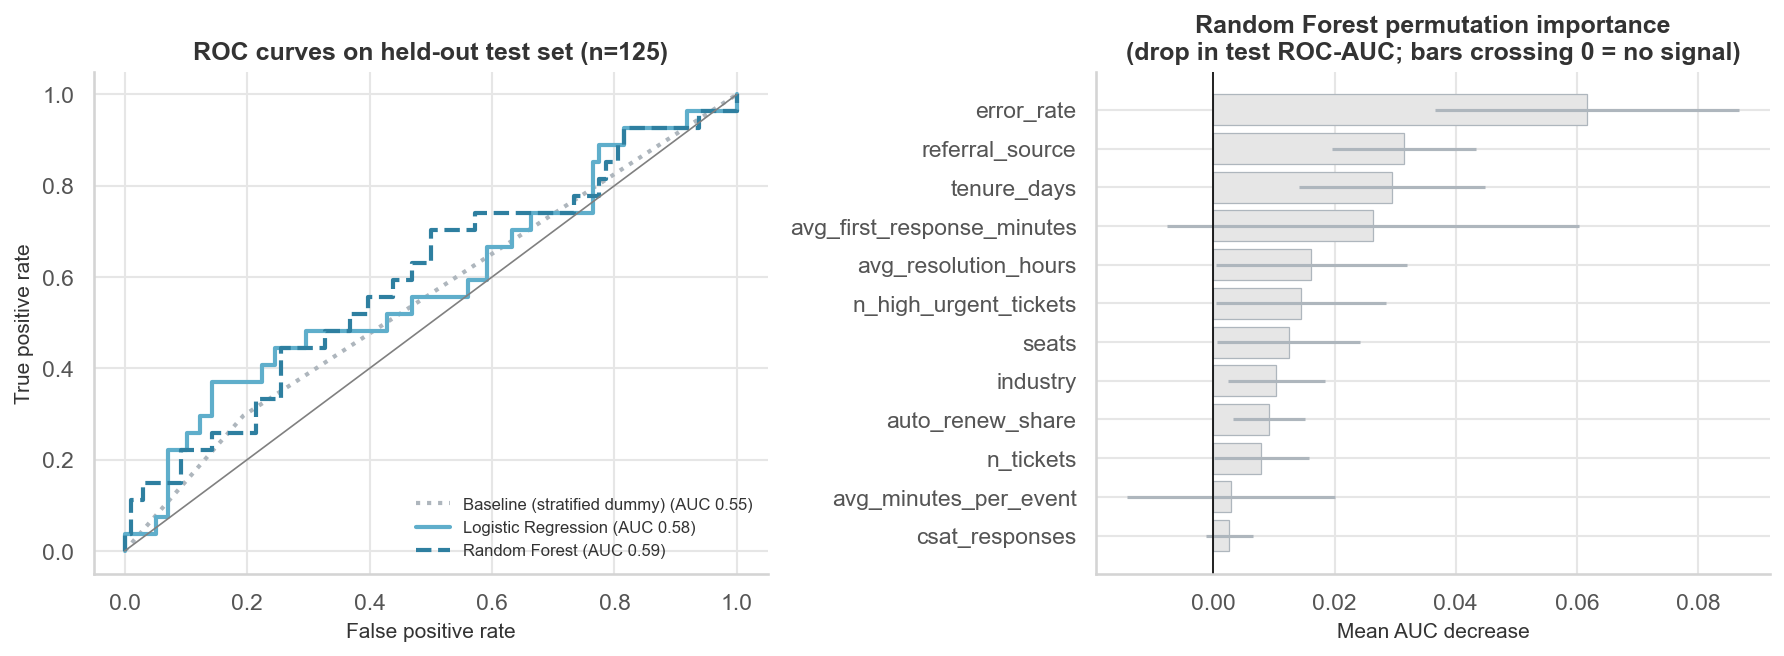

,feature,coefficient,odds_ratio_per_unit
28,cat__country_DE,0.6995,2.0128
23,cat__industry_DevTools,0.5761,1.7792
33,cat__referral_source_event,0.4967,1.6434
29,cat__country_FR,0.4687,1.5979
26,cat__industry_HealthTech,0.4529,1.5729
32,cat__country_US,0.4030,1.4963
35,cat__referral_source_other,0.3336,1.3961
9,num__distinct_features,0.3123,1.3665
12,num__error_rate,-0.3017,0.7396
13,num__beta_event_share,-0.2818,0.7544


,feature,importance_mean,importance_std
12,error_rate,0.0617,0.0251
24,referral_source,0.0315,0.0119
1,tenure_days,0.0295,0.0154
18,avg_first_response_minutes,0.0264,0.0340
17,avg_resolution_hours,0.0162,0.0157
16,n_high_urgent_tickets,0.0145,0.0140
0,seats,0.0125,0.0118
22,industry,0.0104,0.0080
7,auto_renew_share,0.0092,0.0060
14,n_tickets,0.0079,0.0079


In [5]:
display(Image(FIGURES_DIR / "12_churn_model.png"))
display(model["coefficients"].head(10))
model["permutation_importance"].head(10)

Cross-validated ROC-AUC (5×5 repeated stratified CV) is about 0.52 for logistic regression and 0.53 for random forest,
against 0.50 for a stratified dummy baseline. The single 125-account test split gives slightly higher AUCs whose
bootstrap confidence intervals include 0.5. **Conclusion:** the available behavioural and commercial features do not
meaningfully separate churned from retained accounts. The model is not used for decisions, and its feature importances
are not interpreted as churn drivers.

## 3. A/B testing: why none is run, and planning a real experiment

In [6]:
candidate_cols = [c for df in t.values() for c in df.columns if any(k in c.lower() for k in ("experiment", "variant", "treatment", "control", "cohort_group", "exposure"))]
print("experiment-like columns found:", candidate_cols or "none")

experiment-like columns found: none


In [7]:
acc_d90 = ret.account_window_retention(a).query("window_days == 90").retention_rate.iloc[0]
new_per_month = (af.signup_date.dt.year == 2024).sum() / 12
experiment_design.power_table({"account churn rate (churn_flag)": af.churn_flag.mean(),
                               "churn event within 90 days of signup": 1 - acc_d90}, new_per_month)

,metric,baseline_rate (observed),absolute_mde (design choice),target_rate,accounts_per_arm,total_accounts,months_of_new_accounts_needed
0,account churn rate (churn_flag),0.2200,0.0200,0.2000,6508,13016,572.1319
1,account churn rate (churn_flag),0.2200,0.0500,0.1700,983,1966,86.4176
2,account churn rate (churn_flag),0.2200,0.1000,0.1200,218,436,19.1648
3,churn event within 90 days of signup,0.3152,0.0200,0.2952,8320,16640,731.4286
4,churn event within 90 days of signup,0.3152,0.0500,0.2652,1292,2584,113.5824
5,churn event within 90 days of signup,0.3152,0.1000,0.2152,304,608,26.7253


The baselines are observed values. The minimum detectable effects (2 / 5 / 10 pp) are **design choices, not
results**. At about 23 new accounts per month, only very large effects could be detected in a reasonable time. The
full hypothetical design is in `docs/EXPERIMENT_DESIGN.md`.